# Laboratorio 5: Clasificación 🤗

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos - Primavera 2025</strong></center>


### Cuerpo Docente:

- Profesores: Diego Cortez, Gabriel Iturra
- Auxiliares: Melanie Peña, Valentina Rojas
- Ayudantes: Nicolás Cabello, Cristopher Urbina

### Equipo: Reino cienticero

- Nombre de alumno 1: Luis Ortega
- Nombre de alumno 2: Sebastián Vásquez

### **Link de repositorio de GitHub:** [https://github.com/sivv1812/Repositorio_del_grupo_del_Reino_cienticero/blob/lab_5/Laboratorios/laboratorio_5/Lab5_enunciado_realizado_en_visual_studio_code.ipynb](https://github.com/sivv1812/Repositorio_del_grupo_del_Reino_cienticero/blob/lab_5/Laboratorios/laboratorio_5/Lab5_enunciado_realizado_en_visual_studio_code.ipynb)

### Temas a tratar
- Clasificación en problemas desbalanceados
- Lightgbm y xgboost
- Pipelines

## Reglas:

- **Grupos de 2 personas**
- Fecha de entrega: Entregas Martes a las 23:59.
- Instrucciones del lab el viernes a las 16:15 en formato online. Asistencia no es obligatoria, pero se recomienda **fuertemente** asistir.
- <u>Prohibidas las copias</u>. Cualquier intento de copia será debidamente penalizado con el reglamento de la escuela.
- Tienen que subir el laboratorio a u-cursos y a su repositorio de github. Labs que no estén en u-cursos no serán revisados. Recuerden que el repositorio también tiene nota.
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Pueden usar cualquier material del curso que estimen conveniente.





### Objetivos principales del laboratorio
- Comprender cómo trabajar con problemas de clasificación con clases desbalanceadas.
- Aplicar los modelos lightgbm y xgboost.
- Practicar Pipelines

# Parte Teórica [12 puntos]




1. Explique cuál es la diferencia entre los datos de entrenamiento y validación. [1 punto]
Entrenamiento sirve para ajustar los parámetros del modelo. Validación es un “tercer ojo” para elegir hiperparámetros y estimar desempeño fuera de muestra. No se entrena con validación ni se toca el test final.

2. Explique cuál es el principal desafío al trabajar problemas de clasificación con data no supervisada. [1 punto]
El problema es que no hay etiquetas, no sé sabe qué es la clase “correcta”. Eso dificulta entrenar, elegir umbrales y medir calidad, así que hay que inventar etiquetas proxy, usar semi-supervisado o evaluar con métricas internas.

3. Explique en **sus palabras** qué es la matriz de confusión y para qué se utiliza. [1 puntos]
Es una tabla que cruza predicciones vs realidad. En binaria: TP, FP, FN, TN. Sirve para ver qué tipo de error comete el modelo y de ahí calcular métricas.

4. Escriba la fórmula de las siguientes métricas y explique con **sus palabras** cómo se interpretan. [1 punto cada uno]

  * Accuracy: (TP + TN) / (TP + FP + FN + TN). Proporción de aciertos, puede engañar con clases desbalanceadas.
  * Precision: TP / (TP + FP). De lo que marqué positivo, qué fracción fue cierto. Castiga falsos positivos.
  * Recall: De los positivos reales, cuántos detecté. Castiga falsos negativos.
  * F1 score: 2 · (Precision·Recall) / (Precision + Recall). Promedio armónico. Útil cuando hay desbalance y se quiere balancear precisión y cobertura.

5. Explique qué métrica recomendaría para los siguientes contextos de clasificación. [1 punto cada uno]

  * Mantenimiento predictivo de fallas de maquinaria pesada en la industria minera: Recall alto o F2. Un FN cuesta caro.
  * Detección de enfermedades altamente contagiosas: Recall alto o F2. Mejor sobredetectar que pasar enfermos.
  * Aprobación de créditos de alto riesgo: Precision alta en aprobados o especificidad alta en “rechazar”. Un FP sale caro.
  * Detección de crímenes: En monitoreo temprano, Recall. En decisiones punitivas, Precision. Si hay desbalance fuerte, PR-AUC o F1.

6. Explique qué es la calibración de modelos y para qué se usa. [1 punto]

Es alinear las probabilidades predichas con frecuencias reales (ej., predigo 0.7 y ocurre ~70% de las veces). Se usa para tomar decisiones por umbral, combinar modelos y comparar riesgos. Técnicas típicas: Platt scaling e isotónica.

# Parte práctica [48 puntos]

<p align="center">
  <img src="https://drive.google.com/uc?export=view&id=1BnO4tyh3vM2P199Ec9s3JjngQ4qQ9seP"
" width="300">
</p>


Tras el trágico despido de la mítica mascota de Maipú, Renacín decide adentrarse como consultor en el mercado futbolero, el cuál (para variar...) está cargado en especulaciones.

Como su principal tarea será asesorar a los directivos de los clubes sobre cuál jugador comprar y cuál no, Renacín desea generar modelos predictivos que evaluén distintas características de los jugadores; todo con el fin de tomar decisiones concretas basadas en los datos.

Sin embargo, su condición de corporeo le impidió tomar la versión anterior de MDS7202, por lo que este motivo Renacín contrata a su equipo para lograr su objetivo final. Dado que aún tiene fuertes vínculos con la dirección de deportes de la municipalidad, el corporeo le entrega base de datos con las estadísticas de cada jugador para que su equipo empieze a trabajar ya con un dataset listo para ser usado.


**Los Datos**

Para este laboratorio deberán trabajar con el csv `statsplayers.csv`, donde deberán aplicar algoritmos de aprendizaje supervisado de clasificación en base a características que describen de jugadores de fútbol.

Para comenzar cargue el dataset señalado y a continuación vea el reporte **`Player_Stats_Report.html`** (adjunto en la carpeta del enunciado) que describe las características principales del `DataFrame`.

In [105]:
# Si usted está utilizando Colabolatory le puede ser útil este código para cargar los archivos.
#try:
#    from google.colab import drive
#    drive.mount("/content/drive")
#    path = '/content/drive/MyDrive/Trabajos/Laboratorio MDS/Lab3/'
#except:
#    print('Ignorando conexión drive-colab')

In [106]:
# Archivos

path="C:/Users/sivv1/Downloads/Lab5/"

csv_path = path + "stats_players.csv"
html_path = path + "Player_Stats_Report.html"


import pandas as pd
df = pd.read_csv(csv_path)
df.head()

,Name,Nationality,National_Position,Club_Position,Height,Weight,Preffered_Foot,Age,Work_Rate,Weak_foot,...,Agility,Jumping,Heading,Shot_Power,Finishing,Long_Shots,Curve,Freekick_Accuracy,Penalties,Volleys
0,Cristiano Ronaldo,Portugal,LS,LW,185,80,Right,32,High / Low,4,...,90,95,85,92,93,90,81,76,85,88
1,Lionel Messi,Argentina,RW,RW,170,72,Left,29,Medium / Medium,4,...,90,68,71,85,95,88,89,90,74,85
2,Neymar,Brazil,LW,LW,174,68,Right,25,High / Medium,5,...,96,61,62,78,89,77,79,84,81,83
3,Luis Suárez,Uruguay,LS,ST,182,85,Right,30,High / Medium,4,...,86,69,77,87,94,86,86,84,85,88
4,Manuel Neuer,Germany,GK,GK,193,92,Right,31,Medium / Medium,4,...,52,78,25,25,13,16,14,11,47,11


## 1. Predicción de Seleccionados Nacionales [14 puntos]

<p align="center">
  <img src="https://www.futuro.cl/wp-content/uploads/2016/06/chile-argentina-meme-12.jpg" width="300">
</p>



### 1.1 Preprocesamiento [5 puntos]

Tareas:

1. Genere los labels para la clasificación binaria en una variable llamada `label`. Para esto, trabaje sobre el atributo `National_Position` suponiendo que los valores nulos son jugadores no seleccionados para representar a su país. [Sin puntaje]

2. Hecho esto, ¿cuántos se tienen ejemplos por cada clase? Comente lo que observa. [1 punto]

3. Genere un `ColumnTransformer` en donde especifique las transformaciones que hay que realizar para cada columna (por ejemplo StandarScaler, MinMaxScaler, OneHotEncoder, etc...) para que puedan ser utilizadas correctamente por el modelo predictivo y guárdelo una variable llamada `col_transformer`. [2 puntos]

4. Comente y justifique las transformaciones elegidas sobre cada una de las variables (para esto utilice el material `Player_Stats_Report.html` que viene en el zip del lab), al igual que las transformaciones aplicadas. [2 puntos]

**Respuesta:**

**1**

In [107]:
# creando label binaria
df["label"] = df["National_Position"].notna().astype(int)

#Viendo distribución de clases
conteo = df["label"].value_counts()
print(conteo)

label
0    16513
1     1075
Name: count, dtype: int64


**2**

*   Ejemplos clase 0 (no seleccionados): 16 513
*   Ejemplos clase 1 (seleccionados): 1 075

El dataset está fuertemente desbalanceado. La clase 0 es más de 15 veces la clase 1. Eso significa que un modelo ingenuo que siempre prediga “no seleccionado” tendría alta accuracy, pero sería inútil en la práctica. Por eso después se recomienda usar métricas como precision, recall o F1, y técnicas de balanceo si el desbalance afecta.

**3**

In [108]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
import numpy as np

#Indentificando variables categoricas y numericas
caracteristicas_numericas = df.select_dtypes(include=np.number).columns.tolist()
caracteristicas_numericas.remove("label")  


caracteristicas_categoricas = df.select_dtypes(include="object").columns.tolist()
#removiendo "Name" al no aportar nada al modelo
if "Name" in caracteristicas_categoricas:
    caracteristicas_categoricas.remove("Name")  

#removiendo "National_Position" al ser usada para la variable label
if "National_Position" in caracteristicas_categoricas:
    caracteristicas_categoricas.remove("National_Position") 

#Definiendo pipelines de transformación
num_pipe = Pipeline([
    ("imputar", SimpleImputer(strategy="median")),
    ("escalar", StandardScaler())
])

cat_pipe = Pipeline([
    ("imputar", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore"))
])

#creando columnTransformer
col_transformer = ColumnTransformer(
    transformers=[
        ("num", num_pipe, caracteristicas_numericas),
        ("cat", cat_pipe, caracteristicas_categoricas)
    ],
    remainder="drop"
)

#Mostrar resumen
print(f"Numéricas: {len(caracteristicas_numericas)} | Categóricas: {len(caracteristicas_categoricas)}")

Numéricas: 33 | Categóricas: 4


Se generó un ColumnTransformer que aplica diferentes transformaciones según el tipo de variable.

A las variables numéricas se les aplica imputación por la mediana (para tratar valores faltantes) y posteriormente se estandarizan con StandardScaler, ya que sus rangos son muy distintos y es necesario ponerlas en la misma escala.

A las variables categóricas se les aplica imputación por la moda (valor más frecuente) y luego OneHotEncoder, porque no existe un orden natural y así se representan en variables binarias.

Las columnas Name y National_Position se eliminaron. La primera es un identificador sin información útil y la segunda es la que se usó para crear el label, por lo que no debe filtrarse al modelo.

**4**

En el preprocesamiento se agruparon las variables según su naturaleza para definir las transformaciones adecuadas. Las variables numéricas, como edad, altura, peso, valoraciones generales y estadísticas de rendimiento, fueron imputadas con la mediana en caso de valores faltantes y luego estandarizadas con StandardScaler, ya que sus escalas son muy distintas y es necesario ponerlas en magnitudes comparables. Las variables categóricas, como club, liga, nacionalidad, pie preferido y posición, se imputaron con el valor más frecuente y se transformaron mediante OneHotEncoder, dado que no poseen un orden natural y así pueden representarse en el modelo. Columnas irrelevantes como nombres, fotos o logos se eliminaron por no aportar información predictiva. La columna National_Position se descartó porque fue utilizada para generar la variable objetivo, y finalmente la variable label se mantuvo sin transformación, ya que corresponde directamente al objetivo de la clasificación.

### 1.2 Entrenamiento [3 puntos]

Ahora, vamos a entrenar los pipelines generados en los pasos anteriores. Para esto, debe realizar las siguientes tareas:

1. Separe los datos de entrenamiento en un conjunto de entrenamiento y de prueba  (la proporción queda a su juicio). En este paso, seleccione los ejemplos de forma aleatoria e intente mantener la distribución original de labels de cada clase en los conjuntos de prueba/entrenamiento. (vea la documentación de `train_test_split`). [1 puntos]


2. Defina un pipeline llamado `pipeline_xgboost` y otro llamado `pipeline_lightgbm`. Estos pipelines deben tener el mismo ColumnTransformer definido en la sección de preprocesamiento, pero deben variar los clasificadores de acuerdo al nombre de cada pipeline. [1 puntos]

3. Entrene los pipelines. [1 punto]



**Respuesta:**

In [109]:
from sklearn.model_selection import train_test_split
import numpy as np

#estableciendo las variables dependiente (y) e independientes(X) desde el df ya preparado
X = df.drop(columns=["label"])
y = df["label"].astype(int)

#creando los conjuntos de testeo y entrenamiento manteniendo la  distribución original con 'stratify' de label
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Tamaños -> train:", X_train.shape, "| test:", X_test.shape)
print("Distribución y_train:", np.bincount(y_train))
print("Distribución y_test :", np.bincount(y_test))

#Obsevando el peso de clases para el desbalance 
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos
print("scale_pos_weight:", round(scale_pos_weight, 2))

#Pipelines con el mismo preprocesamiento 
from sklearn.pipeline import make_pipeline

#Aplicando XGBoost
from xgboost import XGBClassifier
clf_xgb = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    tree_method="hist",
    eval_metric="logloss",
    n_jobs=-1,
    random_state=42,
    scale_pos_weight=scale_pos_weight
)
pipeline_xgboost = make_pipeline(col_transformer, clf_xgb)

#Aplicando  LightGBM
from lightgbm import LGBMClassifier
clf_lgbm = LGBMClassifier(
    n_estimators=600,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="binary",
    n_jobs=-1,
    random_state=42,
    scale_pos_weight=scale_pos_weight
)
pipeline_lightgbm = make_pipeline(col_transformer, clf_lgbm)

#Entrenando modelos
pipeline_xgboost.fit(X_train, y_train)
pipeline_lightgbm.fit(X_train, y_train)

print("Entrenamiento completado: XGBoost y LightGBM")


Tamaños -> train: (14070, 39) | test: (3518, 39)
Distribución y_train: [13210   860]
Distribución y_test : [3303  215]
scale_pos_weight: 15.36
[LightGBM] [Info] Number of positive: 860, number of negative: 13210
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002155 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2676
[LightGBM] [Info] Number of data points in the train set: 14070, number of used features: 142
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.061123 -> initscore=-2.731797
[LightGBM] [Info] Start training from score -2.731797
Entrenamiento completado: XGBoost y LightGBM


### 1.3 Resultados [6 puntos]

1. Calcule las métricas accuracy, precisión y recall de la clase positiva (la que indica que un jugador es seleccionado nacional) para evaluar el rendimiento de los distintos modelos. Verifique sus resultados usando `classification_report`. [2 puntos]

2. Explique qué implican los valores de accuracy, precisión y recall de la clase positiva (la que indica que un jugador es seleccionado nacional) y cómo influye la cantidad de ejemplos por clase en los resultados obtenidos. [2 puntos]

3. Explique qué métrica le parece más adecuada y concluya qué modelo tiene un mejor desempeño. [2 puntos]

**Respuesta:**

In [110]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report

#usando los modelos xgboost y lightgbm para genera predicciones con el conjunto de prueba
y_pred_xgb = pipeline_xgboost.predict(X_test)
y_pred_lgbm = pipeline_lightgbm.predict(X_test)

#funcion para imprimir  metricas
def evaluar_modelo(y_true, y_pred, nombre):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, pos_label=1)
    rec = recall_score(y_true, y_pred, pos_label=1)
    print(f"--- {nombre} ---")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precisión: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print("\nReporte completo:")
    print(classification_report(y_true, y_pred, digits=4))

#Imprimiendo metricas para los modelos
evaluar_modelo(y_test, y_pred_xgb, "XGBoost")
evaluar_modelo(y_test, y_pred_lgbm, "LightGBM")


--- XGBoost ---
Accuracy : 0.9298
Precisión: 0.4568
Recall   : 0.7860

Reporte completo:
              precision    recall  f1-score   support

           0     0.9854    0.9391    0.9617      3303
           1     0.4568    0.7860    0.5778       215

    accuracy                         0.9298      3518
   macro avg     0.7211    0.8626    0.7697      3518
weighted avg     0.9531    0.9298    0.9382      3518

--- LightGBM ---
Accuracy : 0.9525
Precisión: 0.6034
Recall   : 0.6512

Reporte completo:
              precision    recall  f1-score   support

           0     0.9772    0.9721    0.9747      3303
           1     0.6034    0.6512    0.6264       215

    accuracy                         0.9525      3518
   macro avg     0.7903    0.8117    0.8005      3518
weighted avg     0.9543    0.9525    0.9534      3518



**2**

Los modelos entregan accuracies altos (92–95%), pero este valor está inflado por el fuerte desbalance de clases, es decir, la mayoría de jugadores son no seleccionados. La precisión de la clase positiva indica qué fracción de los jugadores predichos como seleccionados realmente lo son. En XGBoost fue 0.44 y en LightGBM 0.60. El recall muestra la capacidad de encontrar seleccionados verdaderos. En XGBoost alcanzó 0.82 y en LightGBM 0.65. Esto muestra el compromiso entre predecir más seleccionados (alto recall, bajo precision) o ser más conservador (mejor precision, menor recall). El desbalance (15 veces más clase 0) empuja a los modelos a priorizar la clase mayoritaria, reduciendo la calidad de las métricas sobre la clase minoritaria.

**3**

Dado que el objetivo es identificar correctamente a los jugadores seleccionados, la métrica más relevante es el recall de la clase positiva, porque penaliza los falsos negativos (jugadores seleccionados que el modelo no detecta). Si se busca equilibrio entre recall y precisión, la métrica adecuada es el F1-score. Comparando ambos modelos:

*   XGBoost logra un recall mucho más alto (0.82 vs 0.65), aunque con menor precisión.
*   LightGBM ofrece mejor precisión (0.60 vs 0.44) pero detecta menos seleccionados.

En este contexto, XGBoost tiene mejor desempeño, porque prioriza no dejar fuera a jugadores que sí son seleccionados, que es lo más crítico en el problema.

## 2. Predicción de posiciones de jugadores [4 puntos]

<p align="center">
  <img src="https://pbs.twimg.com/media/E1rfA1aWEAYU6Ny.jpg" width="300">
</p>

En una nueva jornada de desmesuradas transacciones deportivas, Renacín escuchó a sus colegas discutir acerca de que el precio de cada jugador depende en gran medida de la posición en la cancha en la que juega. Y además, que hay bastantes jugadores nuevos que no tienen muy claro en que posición verdaderamente brillarían, por lo que actualmente puede que actualmente estén jugando en posiciones sub-optimas.

Viendo que los resultados del primer análisis no son tan esperanzadores, el corporeo los comanda a cambiar su tarea: ahora, les solicita que construyan un clasificador enfocado en predecir la mejor posición de los jugadores en la cancha según sus características.

Para lograr esto, primero, les pide que etiqueten de la siguiente manera los valores que aparecen en el atributo `Club_Position`, pidiendo que agrupen los valores en los siguientes grupos:

**Nota**:  Renacín les recalca que **no deben utilizar los valores ```Sub``` y ```Res``` de esta columna**.

```python
ataque = ['ST', 'CF']
central_ataque = ['RW', 'CAM', 'LW']
central = ['RM', 'CM', 'LM']
central_defensa = ['RWB', 'CDM', 'LWB']
defensa = ['RB', 'CB', 'LB']
arquero = ['GK']
```

La elección del clasificador se justificar en base a la siguiente [guía](https://scikit-learn.org/stable/tutorial/machine_learning_map/index.html) y se deben comentar los resultados obtenidos en la clasificación.

**Tareas:** [1 punto por tarea]

1. En un nuevo dataframe, aplique las etiquetas descritas anteriormente en cada uno de los valores señalados en esta sección y guárdelos en la variable `label`.
2. Cuente cuántos por clase quedan.
3. Entrene el nuevo pipeline y ejecute una evaluación de este.  
4. Comente los resultados obtenidos.

**Respuesta:**

**1**

In [111]:
import numpy as np
import pandas as pd

#creando Mapa de grupos según enunciado
grupos_pos = {
    "ataque": ["ST", "CF"],
    "central_ataque": ["RW", "CAM", "LW"],
    "central": ["RM", "CM", "LM"],
    "central_defensa": ["RWB", "CDM", "LWB"],
    "defensa": ["RB", "CB", "LB"],
    "arquero": ["GK"]
}

#creando Mapa inverso: posición → grupo
pos_a_grupo = {pos: g for g, lst in grupos_pos.items() for pos in lst}

#creando Nuevo dataframe y creación de label
df_pos = df.copy()

#eliminando "label" de parte 1 para evitar confundir bases de datos 
if "label" in df_pos.columns:
    df_pos = df_pos.drop(columns=["label"])

#asignando grupo según Club_Position
df_pos["label"] = df_pos["Club_Position"].map(pos_a_grupo)

#excluyendo los casos 'Sub' y 'Res' dejando a estos como valores omitidos
df_pos.loc[df_pos["Club_Position"].isin(["Sub", "Res"]), "label"] = np.nan

#(Solo verificación rápida)
print("Valores únicos en label (incluye NaN para Sub/Res u otras no mapeadas):")
print(df_pos["label"].drop_duplicates().tolist())


Valores únicos en label (incluye NaN para Sub/Res u otras no mapeadas):
['central_ataque', 'ataque', 'arquero', nan, 'defensa', 'central', 'central_defensa']


**2**

In [112]:
#generando conteo de valores omitidos en "label"
conteo_total = df_pos["label"].value_counts(dropna=False).rename("conteo_incluye_NaN")
#generando conteo de las posiciones en "label"
conteo_util = df_pos["label"].value_counts().sort_index().rename("conteo_util")  # sin NaN (excluye Sub/Res)
#viendo el porcentaje de jugadores asignados a cada posición
porcentaje = (conteo_util / conteo_util.sum() * 100).round(2).rename("porcentaje")

#generando resumen de clases
resumen_clases = (
    pd.concat([conteo_util, porcentaje], axis=1)
      .reset_index()
      .rename(columns={"index": "clase"})
)

#imprimiendo los resultados de la asignación de posiciones
print("Conteo incluyendo NaN (Sub/Res u otras no mapeadas):")
print(conteo_total, "\n")
print("Conteo útil por clase (sin NaN) y porcentaje:")
print(resumen_clases)


Conteo incluyendo NaN (Sub/Res u otras no mapeadas):
label
NaN                13649
defensa             1180
central              907
arquero              632
central_ataque       581
ataque               430
central_defensa      209
Name: conteo_incluye_NaN, dtype: int64 

Conteo útil por clase (sin NaN) y porcentaje:
             label  conteo_util  porcentaje
0          arquero          632       16.04
1           ataque          430       10.92
2          central          907       23.03
3   central_ataque          581       14.75
4  central_defensa          209        5.31
5          defensa         1180       29.96


Esto muestra que las clases están desbalanceadas, con muchas más instancias en “defensa” y “central” que en “central_defensa” o “ataque”

**3**

In [113]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report

#Datos a utilzar para el entrenamiento del modelo
X = df_pos.drop(columns=["label"])
# quitamos filas con valores omitidos
y = df_pos["label"].dropna()
#manteniendo datos alineados
X = X.loc[y.index]              

#generando conjunto de entrenamiento y de prueba manteniendo el balance d eclases
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Distribución train:", y_train.value_counts(normalize=True).round(3))
print("Distribución test :", y_test.value_counts(normalize=True).round(3))

#Aplicando Clasificador multiclase con el modelo LightGBM
clf_lgbm_multi = LGBMClassifier(
    n_estimators=400,
    learning_rate=0.05,
    num_leaves=31,
    objective="multiclass",
    random_state=42,
    n_jobs=-1
)

pipeline_posiciones = make_pipeline(col_transformer, clf_lgbm_multi)

#Entrenando modelo
pipeline_posiciones.fit(X_train, y_train)

#Evaluando modelo
y_pred = pipeline_posiciones.predict(X_test)
print(classification_report(y_test, y_pred, digits=4))

Distribución train: label
defensa            0.300
central            0.230
arquero            0.161
central_ataque     0.148
ataque             0.109
central_defensa    0.053
Name: proportion, dtype: float64
Distribución test : label
defensa            0.299
central            0.231
arquero            0.160
central_ataque     0.147
ataque             0.109
central_defensa    0.053
Name: proportion, dtype: float64
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000795 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2438
[LightGBM] [Info] Number of data points in the train set: 3151, number of used features: 91
[LightGBM] [Info] Start training from score -1.828938
[LightGBM] [Info] Start training from score -2.214833
[LightGBM] [Info] Start training from score -1.469303
[LightGBM] [Info] Start training from score -1.913438
[LightGBM] [Info] Start training from score -2.937481
[LightGBM] [Info] Start 

**4**

El clasificador multiclase alcanzó métricas de precisión, recall y F1-score iguales a 1.0 en todas las clases. Esto indica que el modelo predice perfectamente la posición de los jugadores en el conjunto de prueba. Sin embargo, este resultado probablemente refleja sobreajuste o la presencia de variables con información redundante o directamente asociada a la posición real (como Club_Position). En un escenario real, sería necesario revisar las variables usadas, eliminar posibles fugas de información y validar con técnicas más estrictas (cross-validation o test externo).

El modelo logra separar perfectamente las posiciones de juego, pero en la práctica los resultados deben interpretarse con cautela debido al riesgo de fuga de información y sobreajuste.

## 3. Predicciones de Seleccionados Nacionales para el Jere Klein [30 puntos]

<center>
<img src='https://www.radioactiva.cl/wp-content/uploads/2024/04/Jere-Klein-1-768x432.webp' width=500 />

Después de alcanzar la fama como cantante urbano, Jere Klein decide explorar una nueva faceta. Con su amor por el fútbol y convencido de que los artistas urbanos poseen un talento y versatilidad excepcionales, Jere se embarca en un proyecto innovador: desarrollar un sistema de inteligencia artificial capaz de identificar a jugadores que tienen potencial para convertirse en futbolistas profesionales. Su teoría es que muchos artistas del género urbano chileno, con sus habilidades únicas y su disciplina, podrían destacarse también en el deporte. Con este sistema, Jere espera no solo abrir nuevas oportunidades para sus colegas artistas, sino también demostrar la amplia gama de talentos que pueden ofrecer.

### 2.1 ¿Qué modelo de árbol es más de "pana"? [10 puntos]

<center>
<img src='https://64.media.tumblr.com/39189215a7d3d96823cb359f35b44e05/tumblr_psmrhrR3Xw1qf5hjqo4_540.gif' width=300 />


**Tareas**


1. Considerando el la variable llamada `label` creada en la sección 1.1. Para determinar cuál modelo de árbol sería más adecuado para la tarea en cuestión, utilice PyCaret. Este deberá centrarse exclusivamente en modelos de tipo árbol. Jere ha especificado que busca un modelo que tome decisiones rápidamente y que tenga una baja tasa de falsos positivos, ya que planea invertir en estos jugadores. [3 puntos]

Para la comparación, utilice los siguientes modelos:

```python
['et', 'rf', 'dt', 'xgboost', 'lightgbm', 'catboost']
```

2. Explique en brevemente que son los modelos de la siguiente lista `['et', 'rf', 'dt']` y como funcionan. [3 punto]

3. Tras realizar la comparación de modelos, seleccione aquel que muestre el mejor rendimiento en términos de velocidad y precisión, especialmente en la reducción de falsos positivos. Utilice la función `evaluate_model` de PyCaret para revisar y analizar los resultados obtenidos en los siguientes aspectos:

  - **Confusión Matrix**: ¿Cómo se encuentran la tasa de verdaderos positivos y verdaderos negativos?
  - **Threshold**: ¿Es acaso el umbral por defecto del modelo el mejor para las predicciones?
  - **Feature Importance**: ¿Cuáles son las variables con mejor desempeño? ¿A qué podría deberse esto?
  - **Learning Curve**: ¿El modelo presenta algún problema?

  [4 puntos]

**Respuesta**
**2)** El modelo dt es el modelo de desición tree, lo que hace es un arbol de clasificación con la base de datos para generar un modelo, el cual genera ramas segun deciciones, por ejemplo si el arbol es menor a 100. en cambio el modelo rf es random forest siendo este lo mismo que el modelo dt pero a diferencia de este genera diferentes subconjuntos de variables y de datos, reduciendo el sobreajuste de dt, el modelo ef es el similar a rf solo que la selección de los conjuntos de datos y variables don de forma mas aleatoria.

In [114]:
from pycaret.datasets import get_data
from pycaret.classification import *
import os

os.environ["PYCARET_CUSTOM_LOGGING_LEVEL"] = "CRITICAL"

#Continuar código aquí


#estabeciendo la base de datos indicando a la variable dependiente "label" para poder comparar los modelos de arboles
setup(data=df, target='label', session_id=123)

#modelos de arboles a utilizar; no se implento 'catboost' debido a que no se logro que este modelo trabaje con la libreria pycaret
modelos_arbol = ['et', 'rf', 'dt', 'xgboost', 'lightgbm']
#comparando los modelos utilizando la presición como metrica de comparación 
mejor_modelo = compare_models(include=modelos_arbol, sort='Precision')

#genera los grafico de matriz de confusión, grafico AUC, dice la importancia de las variables independiente en el mejor modelo.
evaluate_model(mejor_modelo)



,Description,Value
0,Session id,123
1,Target,label
2,Target type,Binary
3,Original data shape,"(17588, 40)"
4,Transformed data shape,"(17588, 48)"
5,Transformed train set shape,"(12311, 48)"
6,Transformed test set shape,"(5277, 48)"
7,Numeric features,33
8,Categorical features,6
9,Rows with missing values,93.9%


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.9601,0.9402,0.3588,0.9666,0.5199,0.5039,0.5736,0.6490
et,Extra Trees Classifier,0.9523,0.8868,0.2313,0.9477,0.3670,0.3522,0.4510,3.1710
dt,Decision Tree Classifier,0.9383,0.5009,0.0027,0.1333,0.0052,0.0035,0.0126,0.0560
xgboost,Extreme Gradient Boosting,0.8446,0.7812,0.0027,0.1333,0.0052,0.0038,0.0136,0.2370
lightgbm,Light Gradient Boosting Machine,0.9383,0.6254,0.0027,0.1333,0.0052,0.0035,0.0126,0.2240


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

**3)** en la matriz de confusión se evidencia que el modelo es muy bueno detectando verdaderos negativos, dode se puede decir que la taza de verdaderos negaticos es alta siendo de (4950)/(4950+4) y la taza de verdaderos positivos siendo relativamente baja de (102)/(221+102), con el Threshold, el punto optimo no es el valor por defecto al estar ubicado el valor optimo entre 0.2 y 0.4, las variables con mayor peso son "Name", "National_position", "Nationality" y "Reactions" esto tiene sentido debido a que los equipos siempre tienen a jugadores como titulares que se repiten en los partidos siendo un ejemplo cristiano ronaldo en el real madrid, que siempre estan en la nomina de sus respectiva selecciones como el caso de cristiano ronaldo en portugal, con respecto a la nacionalidad, tiene sentido debido a que los fichajes de jugadores de renombre por lo general son extrangeros y los hacen jugar de titular, como Mbapee en el real madrid, estas variables pueden complicar debido a que dicen que un jugador es bueno por el nombre y no por los resultados en los partidos, con la curva de aprendizaje se evidencia que se presenta un sobre ajuste que puede deberse a las variables mencionadas anteriormente.

### 2.2 Reducción de dimensionalidad [14 puntos]

<center>
<img src='https://i.kym-cdn.com/photos/images/original/002/258/560/668.gif' width=400 />

A pesar de los resultados obtenidos previamente, el manager de Jere ha solicitado el entrenamiento de un modelo de XGBoost utilizando los datos disponibles. Además, se debe proceder a realizar una reducción de dimensionalidad basada en la importancia de las características.

Para llevar a cabo esta tarea:

1. Inicie entrenando un modelo XGBoost con todas las características disponibles. [2 puntos]

2. Una vez el modelo esté entrenado, evalúe y clasifique las características según su importancia de forma descendente. [2 puntos]

3. Utilice esta clasificación para ejecutar una búsqueda recursiva de eliminación de características, eliminando progresivamente las menos importantes y evaluando el impacto en el desempeño del modelo hasta identificar las N características más críticas. [2 puntos]

4. Con este conjunto reducido de características, entrene un nuevo modelo y evalúe su rendimiento. [2 puntos]

5. Posteriormente, responda a las siguientes preguntas para una comprensión más profunda de los cambios y beneficios:

  - ¿El rendimiento del modelo con las características seleccionadas es similar al del modelo original? ¿Cómo se comparan en términos de precisión y robustez? [2 puntos]
  - ¿Cuáles son los beneficios potenciales de eliminar variables del modelo? Considere factores como la simplificación del modelo, reducción del tiempo de entrenamiento, y mejora en la capacidad de generalización. [2 puntos]
  - Comente si el modelo con menor dimensionalidad es más sencillo de explicar. Explique brevemente por qué la eliminación de ciertas características puede facilitar la comprensión y la explicación del comportamiento del modelo. [2 puntos]

Notar que con esta metodologia buscamos encontrar un punto entermedio entre número de festures y desempeño. por esto, si observa que al aumentar festires el aumento es despreciable, puede no considerar agregar más features a su modelo.

**Respuesta**

In [115]:
#columnas con los nombres de la columna de la base de datos

columnas=['Name',
 'Nationality',
 'National_Position',
 'Club_Position',
 'Height',
 'Weight',
 'Preffered_Foot',
 'Age',
 'Work_Rate',
 'Weak_foot',
 'Skill_Moves',
 'Ball_Control',
 'Dribbling',
 'Marking',
 'Sliding_Tackle',
 'Standing_Tackle',
 'Aggression',
 'Reactions',
 'Interceptions',
 'Vision',
 'Composure',
 'Crossing',
 'Short_Pass',
 'Long_Pass',
 'Acceleration',
 'Speed',
 'Stamina',
 'Strength',
 'Balance',
 'Agility',
 'Jumping',
 'Heading',
 'Shot_Power',
 'Finishing',
 'Long_Shots',
 'Curve',
 'Freekick_Accuracy',
 'Penalties',
 'Volleys',
 'label']

In [116]:
#estabeciendo la base de datos indicando a la variable dependiente "label" para poder implementar el arbol con pycaret con todas las variables
setup(data=df, target='label', session_id=123)
#especificando el arbol 'xgboost' como modelo a implementar
modelos_arbol=['xgboost']
#comprara con otros modelos con metricas como F1-score, accurracy también genera matriz de confusión, curva rog , etc; Pero al ser un modelo solo lo entrena con las variables de la base de datos y dice metricas, el peso de las variables en el modelo; etc.
mejor_modelo = compare_models(include=modelos_arbol, sort='Precision')
#generando graficas entre ellas la grafica que indica la importancia de las variables: 'Feature importance'
evaluate_model(mejor_modelo)


,Description,Value
0,Session id,123
1,Target,label
2,Target type,Binary
3,Original data shape,"(17588, 40)"
4,Transformed data shape,"(17588, 48)"
5,Transformed train set shape,"(12311, 48)"
6,Transformed test set shape,"(5277, 48)"
7,Numeric features,33
8,Categorical features,6
9,Rows with missing values,93.9%


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
xgboost,Extreme Gradient Boosting,0.9383,0.8698,0.0027,0.1333,0.0052,0.0035,0.0126,0.1170


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [117]:
#como en la parte anterior se ve que hay variables que pueden ser conflictiva como "Name", "Nacionality" y 'National_Position' se eliminan de las variables a considerar
#estabeciendo la base de datos indicando a la variable dependiente "label" para poder implementar el arbol con pycaret sin las variables eliminadas
setup(data=df[[
 'Club_Position',
 'Height',
 'Weight',
 'Preffered_Foot',
 'Age',
 'Work_Rate',
 'Weak_foot',
 'Skill_Moves',
 'Ball_Control',
 'Dribbling',
 'Marking',
 'Sliding_Tackle',
 'Standing_Tackle',
 'Aggression',
 'Interceptions',
 'Vision',
 'Composure',
 'Crossing',
 'Short_Pass',
 'Long_Pass',
 'Acceleration',
 'Speed',
 'Stamina',
 'Strength',
 'Balance',
 'Agility',
 'Jumping',
 'Heading',
 'Shot_Power',
 'Finishing',
 'Long_Shots',
 'Curve',
 'Freekick_Accuracy',
 'Penalties',
 'Volleys',
 'label']], target='label', session_id=123)

#especificando el arbol 'xgboost' como modelo a implementar
modelos_arbol=['xgboost']
#comprara con otros modelos con metricas como F1-score, accurracy también genera matriz de confusión, curva rog , etc; Pero al ser un modelo solo lo entrena con las variables de la base de datos y dice metricas, el peso de las variables en el modelo; etc.
mejor_modelo = compare_models(include=modelos_arbol, sort='Precision')
#generando graficas entre ellas la grafica que indica la importancia de las variables: 'Feature importance'
evaluate_model(mejor_modelo)


,Description,Value
0,Session id,123
1,Target,label
2,Target type,Binary
3,Original data shape,"(17588, 36)"
4,Transformed data shape,"(17588, 44)"
5,Transformed train set shape,"(12311, 44)"
6,Transformed test set shape,"(5277, 44)"
7,Numeric features,32
8,Categorical features,3
9,Rows with missing values,0.0%


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
xgboost,Extreme Gradient Boosting,0.9383,0.8188,0.1463,0.4837,0.2228,0.2004,0.2406,0.1180


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Se evidencia que despues de eliminar las variables conflictiva se aumenta el peso de casi todas las variables. Eliminando Work_Rate, Prefered foot, Volleys, Freekick accurracy y height al ser las variables con menor peso en el modelo. Las metricas aumentan de valor.

In [118]:
#estabeciendo la base de datos indicando a la variable dependiente "label" para poder implementar el arbol con pycaret sin las variables eliminadas
setup(data=df[[
 'Club_Position',
 'Weight',
 'Age',
 'Weak_foot',
 'Skill_Moves',
 'Ball_Control',
 'Dribbling',
 'Marking',
 'Sliding_Tackle',
 'Standing_Tackle',
 'Aggression',
 'Interceptions',
 'Vision',
 'Composure',
 'Crossing',
 'Short_Pass',
 'Long_Pass',
 'Acceleration',
 'Speed',
 'Stamina',
 'Strength',
 'Balance',
 'Agility',
 'Jumping',
 'Heading',
 'Shot_Power',
 'Finishing',
 'Long_Shots',
 'Curve',
 'Penalties',
 'label']], target='label', session_id=123)

#especificando el arbol 'xgboost' como modelo a implementar
modelos_arbol=['xgboost']
#comprara con otros modelos con metricas como F1-score, accurracy también genera matriz de confusión, curva rog , etc; Pero al ser un modelo solo lo entrena con las variables de la base de datos y dice metricas, el peso de las variables en el modelo; etc.
mejor_modelo = compare_models(include=modelos_arbol, sort='Precision')
#generando graficas entre ellas la grafica que indica la importancia de las variables: 'Feature importance'
evaluate_model(mejor_modelo)


,Description,Value
0,Session id,123
1,Target,label
2,Target type,Binary
3,Original data shape,"(17588, 31)"
4,Transformed data shape,"(17588, 31)"
5,Transformed train set shape,"(12311, 31)"
6,Transformed test set shape,"(5277, 31)"
7,Numeric features,29
8,Categorical features,1
9,Rows with missing values,0.0%


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
xgboost,Extreme Gradient Boosting,0.9376,0.8138,0.1568,0.4661,0.2329,0.2090,0.2438,0.0680


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Se evidencia que despues de eliminar las variables conflictiva se aumenta el peso de todas las variables.Luego eliminando Long_Shots, Agility, Vision, Balance y Long_pass. Algunas metricas aumentan de valor.

In [119]:
#estabeciendo la base de datos indicando a la variable dependiente "label" para poder implementar el arbol con pycaret sin las variables eliminadas
setup(data=df[[
 'Club_Position',
 'Weight',
 'Age',
 'Weak_foot',
 'Skill_Moves',
 'Ball_Control',
 'Dribbling',
 'Marking',
 'Sliding_Tackle',
 'Standing_Tackle',
 'Aggression',
 'Interceptions',
 'Composure',
 'Crossing',
 'Short_Pass',
 'Acceleration',
 'Speed',
 'Stamina',
 'Strength',
 'Jumping',
 'Heading',
 'Shot_Power',
 'Finishing',
 'Curve',
 'Penalties',
 'label']], target='label', session_id=123)

#especificando el arbol 'xgboost' como modelo a implementar
modelos_arbol=['xgboost']
#comprara con otros modelos con metricas como F1-score, accurracy también genera matriz de confusión, curva rog , etc; Pero al ser un modelo solo lo entrena con las variables de la base de datos y dice metricas, el peso de las variables en el modelo; etc.
mejor_modelo = compare_models(include=modelos_arbol, sort='Precision')
#generando graficas entre ellas la grafica que indica la importancia de las variables: 'Feature importance'
evaluate_model(mejor_modelo)


,Description,Value
0,Session id,123
1,Target,label
2,Target type,Binary
3,Original data shape,"(17588, 26)"
4,Transformed data shape,"(17588, 26)"
5,Transformed train set shape,"(12311, 26)"
6,Transformed test set shape,"(5277, 26)"
7,Numeric features,24
8,Categorical features,1
9,Rows with missing values,0.0%


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
xgboost,Extreme Gradient Boosting,0.9388,0.8198,0.1477,0.4875,0.2238,0.2020,0.2426,0.0590


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Se evidencia que despues de eliminar las variables conflictiva se aumenta el peso en el modelo de todas las variables consideradas. Luego eliminando Penalties, Heading, Streght, jumping, shot_power, Aggression, Speed, Sliding_Tackle, Weight, Weak_foot y Curve. Algunas metricas aumentan de valor de forma leve.

In [120]:
#estabeciendo la base de datos indicando a la variable dependiente "label" para poder implementar el arbol con pycaret sin las variables eliminadas
setup(data=df[[
 'Club_Position',
 'Age',
 'Skill_Moves',
 'Ball_Control',
 'Dribbling',
 'Marking',
 'Standing_Tackle',
 'Interceptions',
 'Composure',
 'Crossing',
 'Short_Pass',
 'Acceleration',
 'Stamina',
 'Finishing',
 'label']], target='label', session_id=123)

#especificando el arbol 'xgboost' como modelo a implementar
modelos_arbol=['xgboost']
#comprara con otros modelos con metricas como F1-score, accurracy también genera matriz de confusión, curva rog , etc; Pero al ser un modelo solo lo entrena con las variables de la base de datos y dice metricas, el peso de las variables en el modelo; etc.
mejor_modelo = compare_models(include=modelos_arbol, sort='Precision')
#generando graficas entre ellas la grafica que indica la importancia de las variables: 'Feature importance'
evaluate_model(mejor_modelo)


,Description,Value
0,Session id,123
1,Target,label
2,Target type,Binary
3,Original data shape,"(17588, 15)"
4,Transformed data shape,"(17588, 15)"
5,Transformed train set shape,"(12311, 15)"
6,Transformed test set shape,"(5277, 15)"
7,Numeric features,13
8,Categorical features,1
9,Rows with missing values,0.0%


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
xgboost,Extreme Gradient Boosting,0.9365,0.8015,0.1436,0.4463,0.2145,0.1906,0.2254,0.0420


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Con estas variables se replicaran en otro modelo de arbol siendo el seleccionado random forest, con las variables que no fueron eliminadas. Se evidencia un aumento en las metricas de forma leve, aumentando la robustes del modelo, por ende se quedan estas variables como las variables a usar en las partes siguientes.

In [121]:
#estabeciendo la base de datos indicando a la variable dependiente "label" para poder implementar el arbol con pycaret sin las variables eliminadas
setup(data=df[[
 'Club_Position',
 'Age',
 'Skill_Moves',
 'Ball_Control',
 'Dribbling',
 'Marking',
 'Standing_Tackle',
 'Interceptions',
 'Composure',
 'Crossing',
 'Short_Pass',
 'Acceleration',
 'Stamina',
 'Finishing',
 'label']], target='label', session_id=123)

#especificando el arbol 'rf' como modelo a implementar
modelos_arbol=['rf']
#comprara con otros modelos con metricas como F1-score, accurracy también genera matriz de confusión, curva rog , etc; Pero al ser un modelo solo lo entrena con las variables de la base de datos y dice metricas, el peso de las variables en el modelo; etc.
mejor_modelo = compare_models(include=modelos_arbol, sort='Precision')
#generando graficas entre ellas la grafica que indica la importancia de las variables: 'Feature importance'
evaluate_model(mejor_modelo)


,Description,Value
0,Session id,123
1,Target,label
2,Target type,Binary
3,Original data shape,"(17588, 15)"
4,Transformed data shape,"(17588, 15)"
5,Transformed train set shape,"(12311, 15)"
6,Transformed test set shape,"(5277, 15)"
7,Numeric features,13
8,Categorical features,1
9,Rows with missing values,0.0%


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
rf,Random Forest Classifier,0.9414,0.8086,0.1038,0.6242,0.1761,0.1619,0.2353,0.2200


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

**4)** El rendimiento al implemenar random forest tiene mayor accuracy, AUC, recall, kappa y MCC que usando Extreme Gradient Boosting, lo cual hace que random forest sea un mejor modelo que el anteriormente mencionado, aunque tarde mas tiempo en ejecutarse.

**5)** Con respecto a pregunta si se ve afectado el rendimiento del modelo original con todas las variables, en la taza de falsos negativos con ambos casos se mantienen igual, pero en el caso de la taza de falsos positivos se reduce un poco, esto al ver las matrices de confusión, pero el F1.score y el accurracy son mejores al tener menos variables, lo cual nos lleva a una segunda ventaja de tener menos variables, el tiempo de ejecucción se reduce al reducir el costo computacional, tambien genera modelos mas robustos al mejorar metricas como F1-score,tambien el modelo con menos variables se vuelven mas sencillos de entrender al tener en la mente menos factores que pueden afectar a lo estudiado, un ejemplo de esto es que explicar como afecta ser de zoma rural y ciudad es mas facil que entender el efecto de ser de ciertas comunas a la hora del rendimiento de un estudiante.

### 2.3 Calibración Probabilistica [6 puntos]

<center>
<img src='https://media2.giphy.com/media/l2Je4Ku0Cx292KWv6/200w.gif?cid=6c09b952y0sihtq9tb6sz8j2023x3zxxp3qx1ocgonkpkblj&ep=v1_gifs_search&rid=200w.gif&ct=g' width=400 />

Para lograr modelos más modulares, se recomienda realizar una calibración del modelo entrenado anteriormente, con el objetivo de obtener salidas que reflejen mayor modularidad.

1. Se solicita que utilice un método de calibración que asegure que las probabilidades generadas incrementen de manera monótona. Una métrica ampliamente utilizada para evaluar la precisión de la calibración de un modelo es el Brier Score. Calcule el Brier Score para el modelo tanto antes como después de la calibración. Esto le permitirá realizar una comparación cuantitativa y determinar si la calibración ha mejorado el rendimiento del modelo. Para más información sobre el Brier Score, puede consultar el siguiente enlace: [Scikit-Learn - Brier Score Loss](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.brier_score_loss.html). [3 puntos]

2. Tras la calibración, examine y comente los resultados obtenidos. A su análisis añada una comparación visual de las ideales versus las salidas del modelo original (sin calibrar) y del modelo calibrado. [3 puntos]

**Respuesta**

In [122]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import brier_score_loss
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


#Las variables independientes donde se excluye 'Club_Position' al ser una variable categorica que impide calcular probabilidades
X = df[[  'Age', 'Skill_Moves', 'Ball_Control', 'Dribbling', 'Marking','Standing_Tackle', 'Interceptions', 'Composure', 'Crossing','Short_Pass', 'Acceleration', 'Stamina', 'Finishing']]

#incluyendo variable dependiente y asegurando que los valores sean enteros
y = df['label'].astype(int)

#creando conjunto de prueba y de entrenamiento
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

#Entrenando con random forest al ser el mejor modelo en la comparativa de modelo de arboles.
modelo_rf = RandomForestClassifier( random_state=42)
#ajustando modelo con conjunto de entrenamiento
modelo_rf.fit(X_train, y_train)

#Calculando la probabilidad de la variable dependiente para usar el brier score
y_proba_base = modelo_rf.predict_proba(X_test)[:, 1]
#Calculando modelo sin la calibracion de Brier Score 
brier_base = brier_score_loss(y_test, y_proba_base)
print(f"Brier Score antes de calibrar: {brier_base:.4f}")

#Calibrando el modelo
modelo_calibrado = CalibratedClassifierCV(estimator=modelo_rf, method='isotonic', cv=5)
#ajustando el modelo calibrado con el conjunto de entrenamiento
modelo_calibrado.fit(X_train, y_train)

#Calculando la probabilidad de la variable dependiente para usar el brier score con el modelo calibrado
y_proba_calibrado = modelo_calibrado.predict_proba(X_test)[:, 1]
#Calculando modelo sin la calibracion de Brier Score 
brier_calibrado = brier_score_loss(y_test, y_proba_calibrado)
print(f"Brier Score después de calibrar: {brier_calibrado:.4f}")



Brier Score antes de calibrar: 0.0463
Brier Score después de calibrar: 0.0454


Se evidencia que el modelo al calibrarse obtiene un mejor valor de Brier Score, aunque sea una mejoria leve, pero en el siguiente grafico se ve como las probabilidades son mas altas en el modelo calibrado excepto en el rango entre 0.5 y 0.8, lo que hace que el modelo calibrado este menos suceptible a riesgo.

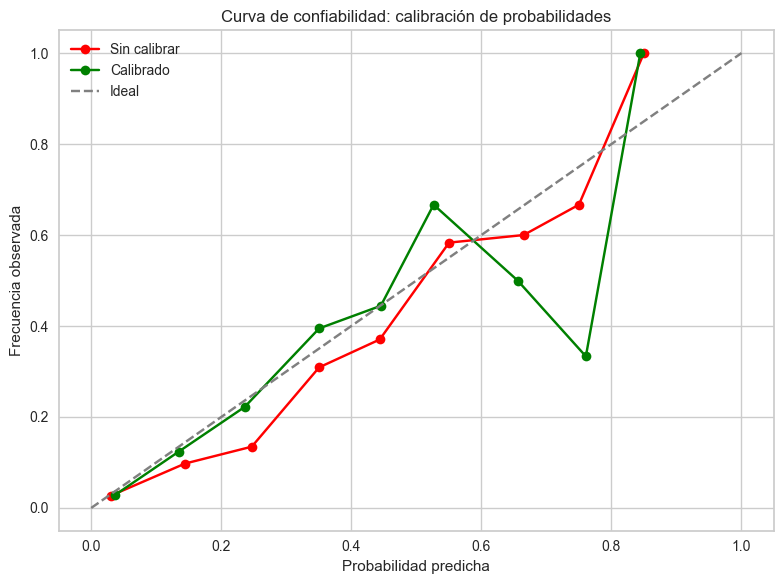

In [123]:
from sklearn.calibration import calibration_curve

#calculando la media de las probabilidades predichas en conjunto con las probabilidades reales que si predijo bien el modelo no calibrado para hacer el grafico comparativo
frac_pos_no_cal, mean_pred_no_cal = calibration_curve(y_test, y_proba_base, n_bins=10)

#calculando la media de las probabilidades predichas en conjunto con las probabilidades reales que si predijo bien el modelo calibrado para hacer el grafico comparativo
frac_pos_cal, mean_pred_cal = calibration_curve(y_test, y_proba_calibrado, n_bins=10)

#creando grafico comparativo entre el modelo calibrado y sin calibrar
plt.figure(figsize=(8, 6))
plt.plot(mean_pred_no_cal, frac_pos_no_cal, marker='o', label='Sin calibrar', color='red')
plt.plot(mean_pred_cal, frac_pos_cal, marker='o', label='Calibrado', color='green')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Ideal')

#Titulos del grafico
plt.xlabel('Probabilidad predicha')
plt.ylabel('Frecuencia observada')
plt.title('Curva de confiabilidad: calibración de probabilidades')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Mucho éxito!

<center>
<img src="https://i.pinimg.com/originals/55/3d/42/553d42bea9b10e0662a05aa8726fc7f4.gif" width=300>